In [1]:
# ── Вкажіть шляхи до файлів докінгу ──────────────────────────────────────────
DOCKING_FILES = [
    "../data/docking_outputs/docking_summary_stats_1.csv",
    "../data/docking_outputs/docking_summary_stats_2.csv",
    "../data/docking_outputs/docking_summary_stats_3.csv",
    "../data/docking_outputs/docking_summary_stats_4.csv",
]

# ── Вкажіть шлях до файлу зі структурами ─────────────────────────────────────
STRUCTURES_FILE = "../data/link_invent_outputs/scored_sampling_test_protac_ranked.csv"

# ── Назва вихідного файлу ─────────────────────────────────────────────────────
OUTPUT_FILE = "../data/docking_outputs/merged_docking_results.csv"

In [3]:
import os
import re
import pandas as pd

In [4]:
docking_dfs = []
for f in DOCKING_FILES:
    if not os.path.exists(f):
        raise FileNotFoundError(f"Файл не знайдено: {f}")
    df = pd.read_csv(f)
    df["Source_File"] = os.path.basename(f)
    print(f"  {f}  →  {len(df)} рядків")
    docking_dfs.append(df)

docking_df = pd.concat(docking_dfs, ignore_index=True)

before = len(docking_df)
docking_df = docking_df.drop_duplicates(subset=["Compound"])
if before != len(docking_df):
    print(f"Видалено {before - len(docking_df)} дублікат(ів).")

print(f"\nУсього унікальних сполук: {len(docking_df)}")
docking_df.head()

  ../data/docking_outputs/docking_summary_stats_1.csv  →  51 рядків
  ../data/docking_outputs/docking_summary_stats_2.csv  →  8 рядків
  ../data/docking_outputs/docking_summary_stats_3.csv  →  34 рядків
  ../data/docking_outputs/docking_summary_stats_4.csv  →  7 рядків

Усього унікальних сполук: 100


,Compound,Run_1,Run_2,Run_3,Run_4,Run_5,Best_Score,Source_File
0,Compound_rank_5,-19.8062,-22.5594,-20.2530,-21.8296,-22.9509,-22.9509,docking_summary_stats_1.csv
1,Compound_rank_6,-33.7561,-38.3496,-23.7901,-26.3746,-36.0692,-38.3496,docking_summary_stats_1.csv
2,Compound_rank_7,-28.3239,-24.8037,-30.7373,-28.6216,-27.7064,-30.7373,docking_summary_stats_1.csv
3,Compound_rank_8,-22.3808,-18.9645,-19.8494,-24.0290,-25.9416,-25.9416,docking_summary_stats_1.csv
4,Compound_rank_9,-23.1629,-31.2848,-30.6848,-29.2740,-24.2705,-31.2848,docking_summary_stats_1.csv


In [5]:
def extract_rank(name: str):
    m = re.search(r"rank_(\d+)", str(name), re.IGNORECASE)
    return int(m.group(1)) if m else None

docking_df["Rank"] = docking_df["Compound"].apply(extract_rank)

missing = docking_df["Rank"].isna().sum()
if missing:
    print(f"⚠️  {missing} сполук(а) без номера рангу в назві.")
else:
    print("✓ Ранги успішно витягнуто для всіх сполук.")

docking_df[["Compound", "Rank", "Best_Score"]].head()

✓ Ранги успішно витягнуто для всіх сполук.


,Compound,Rank,Best_Score
0,Compound_rank_5,5,-22.9509
1,Compound_rank_6,6,-38.3496
2,Compound_rank_7,7,-30.7373
3,Compound_rank_8,8,-25.9416
4,Compound_rank_9,9,-31.2848


In [6]:
if not os.path.exists(STRUCTURES_FILE):
    raise FileNotFoundError(f"Файл структур не знайдено: {STRUCTURES_FILE}")

structures_df = pd.read_csv(STRUCTURES_FILE)

if "Rank" not in structures_df.columns:
    raise ValueError(
        f"Очікується стовпець 'Rank' у файлі структур. "
        f"Наявні стовпці: {list(structures_df.columns)}"
    )

print(f"Завантажено: {STRUCTURES_FILE}  →  {len(structures_df)} рядків")
structures_df.head()

Завантажено: ../data/link_invent_outputs/scored_sampling_test_protac_ranked.csv  →  100 рядків


,SMILES,SMILES_state,Warheads,Linker,NLL,Active_Class,Active_Probability,Epistemic_Uncertainty,Rank
0,CC1CC(n2cc(-c3cccc(S(=O)(=O)Nc4ccc5c(c4)n(C)c(...,1,*c1c(F)c(S(=O)(=O)Nc2ccc3n(C)c(=O)n(C)c3c2)ccc...,C1(C)C(C)CC(n2nnc([*])c2)CCC1c1nn(C)cc1[*],9.15,0,0.797555,0.342779,1
1,Cn1cc(-c2cccc(S(=O)(=O)Nc3ccc4c(c3)n(C)c(=O)n4...,1,*c1c(F)c(S(=O)(=O)Nc2ccc3n(C)c(=O)n(C)c3c2)ccc...,C1CC(C(c2nn(C)cc2[*])=O)CCC1c1nn(C)cc1[*],6.42,0,0.795119,0.339806,2
2,CC1CC(c2cncc(-c3cccc(S(=O)(=O)Nc4ccc5c(c4)n(C)...,1,*c1c(F)c(S(=O)(=O)Nc2ccc3n(C)c(=O)n(C)c3c2)ccc...,C1C(C)CC(c2nc([*])cnc2)CCC1c1nn(C)cc1[*],13.35,0,0.795101,0.338201,3
3,CC1CC(n2cc(-c3cccc(S(=O)(=O)Nc4ccc5c(c4)n(C)c(...,1,*c1c(F)c(S(=O)(=O)Nc2ccc3n(C)c(=O)n(C)c3c2)ccc...,C1(C)CC(n2nnc([*])c2)CCC1c1nn(C)cc1[*],6.67,0,0.793259,0.336448,4
4,CC(c1c(-c2cccc(S(=O)(=O)Nc3ccc4c(c3)CN(C)C(=O)...,1,*c1c(Cl)c(S(=O)(=O)Nc2ccc3NC(=O)N(C)Cc3c2)ccc1...,C1(C)C(C(c2n(C)ncc2[*])C)CCC1c1nn(C)cc1[*],10.10,0,0.792812,0.322638,5


In [7]:
structure_cols = [c for c in structures_df.columns if c != "Rank"]

merged_df = docking_df.merge(
    structures_df,
    on="Rank",
    how="left",
    suffixes=("_docking", "_structure"),
)

# Зручний порядок стовпців
docking_score_cols = ["Compound", "Rank", "Run_1", "Run_2", "Run_3", "Run_4", "Run_5", "Best_Score", "Source_File"]
final_cols = [c for c in docking_score_cols + structure_cols if c in merged_df.columns]
merged_df = merged_df[final_cols]

matched   = merged_df[structure_cols[0]].notna().sum()
unmatched = len(merged_df) - matched

print(f"Результат merge:")
print(f"  Усього рядків : {len(merged_df)}")
print(f"  Збіглося      : {matched}")
print(f"  Без структури : {unmatched}")

merged_df.head()

Результат merge:
  Усього рядків : 100
  Збіглося      : 100
  Без структури : 0


,Compound,Rank,Run_1,Run_2,Run_3,Run_4,Run_5,Best_Score,Source_File,SMILES,SMILES_state,Warheads,Linker,NLL,Active_Class,Active_Probability,Epistemic_Uncertainty
0,Compound_rank_5,5,-19.8062,-22.5594,-20.2530,-21.8296,-22.9509,-22.9509,docking_summary_stats_1.csv,CC(c1c(-c2cccc(S(=O)(=O)Nc3ccc4c(c3)CN(C)C(=O)...,1,*c1c(Cl)c(S(=O)(=O)Nc2ccc3NC(=O)N(C)Cc3c2)ccc1...,C1(C)C(C(c2n(C)ncc2[*])C)CCC1c1nn(C)cc1[*],10.10,0,0.792812,0.322638
1,Compound_rank_6,6,-33.7561,-38.3496,-23.7901,-26.3746,-36.0692,-38.3496,docking_summary_stats_1.csv,CN1Cc2cc(NS(=O)(=O)c3cccc(-c4cncc(OCC5CCCC5c5n...,1,*c1c(Cl)c(S(=O)(=O)Nc2ccc3NC(=O)N(C)Cc3c2)ccc1...,C1(COc2nc([*])cnc2)CCCC1c1nn(C)cc1[*],11.17,0,0.790472,0.325994
2,Compound_rank_7,7,-28.3239,-24.8037,-30.7373,-28.6216,-27.7064,-30.7373,docking_summary_stats_1.csv,CC1C(C(=O)c2ncc(-c3cccc(S(=O)(=O)Nc4ccc5c(c4)C...,1,*c1c(Cl)c(S(=O)(=O)Nc2ccc3NC(=O)N(C)Cc3c2)ccc1...,C1(C)C(C(=O)c2oc([*])cn2)CCCC1c1nn(C)cc1[*],12.23,0,0.788421,0.316858
3,Compound_rank_8,8,-22.3808,-18.9645,-19.8494,-24.0290,-25.9416,-25.9416,docking_summary_stats_1.csv,Cc1nc(C2CCCC(c3c(Nc4cccc5c4CN(C4CCC(=O)NC4=O)C...,1,*c1c(Cl)c(S(=O)(=O)Nc2ccc3NC(=O)N(C)Cc3c2)ccc1...,C1C(c2nc(C)sc2[*])CCCC1c1n(C)ncc1[*],12.51,0,0.783442,0.307886
4,Compound_rank_9,9,-23.1629,-31.2848,-30.6848,-29.2740,-24.2705,-31.2848,docking_summary_stats_1.csv,CC1C(Cc2cccc(S(=O)(=O)Nc3ccc4c(c3)CN(C)C(=O)N4...,1,*c1c(Cl)c(S(=O)(=O)Nc2ccc3NC(=O)N(C)Cc3c2)ccc1...,C1(C)C(C[*])CCC1c1n(C)ncc1[*],6.13,0,0.782887,0.316085


In [8]:
merged_df.to_csv(OUTPUT_FILE, index=False)
print(f"✓ Збережено → {OUTPUT_FILE}")

✓ Збережено → ../data/docking_outputs/merged_docking_results.csv


In [11]:
# ── Статистика по скорах докінгу ──────────────────────────────────────────────

run_cols = ["Run_1", "Run_2", "Run_3", "Run_4", "Run_5"]
merged_df = pd.read_csv(OUTPUT_FILE)
stats_df = merged_df.copy()

# Базова статистика по рядках
stats_df["Min_Score"]    = stats_df[run_cols].min(axis=1)
stats_df["Max_Score"]    = stats_df[run_cols].max(axis=1)
stats_df["Avg_Score"]    = stats_df[run_cols].mean(axis=1)
stats_df["Median_Score"] = stats_df[run_cols].median(axis=1)

# Стандартне відхилення — показує розкид між запусками
stats_df["Std_Score"]    = stats_df[run_cols].std(axis=1)

# Розмах (Range) — різниця між найкращим і найгіршим запуском
stats_df["Range_Score"]  = stats_df["Max_Score"] - stats_df["Min_Score"]

# Коефіцієнт варіації (CV, %) — відносний розкид, незалежний від масштабу скору
# Низький CV (~<10%) → запуски збігаються, результат стабільний
# Високий CV (>20%)  → велика варіативність, варто інтерпретувати обережно
stats_df["CV_%"]         = (stats_df["Std_Score"] / stats_df["Avg_Score"].abs() * 100).round(2)

# Збіжність: частка запусків у межах 10% від Best_Score
stats_df["Convergence"] = stats_df["Avg_Score"] - stats_df["Best_Score"]

# Ранжування за середнім скором (чим менше — тим краще у докінгу)
stats_df["Rank_by_Avg"]  = stats_df["Avg_Score"].rank(ascending=True).astype(int)

print("=== Статистика по сполуках ===")
display_cols = ["Compound", "Best_Score", "Min_Score", "Max_Score",
                "Avg_Score", "Median_Score", "Std_Score", "Range_Score",
                "CV_%", "Convergence", "Rank_by_Avg"]
display(stats_df[display_cols].sort_values("Avg_Score"))

=== Статистика по сполуках ===


,Compound,Best_Score,Min_Score,Max_Score,Avg_Score,Median_Score,Std_Score,Range_Score,CV_%,Convergence,Rank_by_Avg
75,Compound_rank_34,-38.1869,-38.1869,-33.9938,-35.90284,-35.7974,1.497839,4.1931,4.17,2.28406,1
57,Compound_rank_87,-37.1345,-37.1345,-29.4731,-34.28148,-34.5917,3.015966,7.6614,8.80,2.85302,2
24,Compound_rank_50,-37.1269,-37.1269,-29.8813,-33.01332,-31.4969,3.373330,7.2456,10.22,4.11358,3
45,Compound_rank_92,-35.5845,-35.5845,-25.4267,-32.78688,-34.6981,4.248614,10.1578,12.96,2.79762,4
47,Compound_rank_96,-35.0443,-35.0443,-30.1173,-32.44114,-32.8255,1.981492,4.9270,6.11,2.60316,5
...,...,...,...,...,...,...,...,...,...,...,...
0,Compound_rank_5,-22.9509,-22.9509,-19.8062,-21.47982,-21.8296,1.392660,3.1447,6.48,1.47108,96
62,Compound_rank_4,-23.5010,-23.5010,-18.6508,-21.07622,-20.0479,2.156824,4.8502,10.23,2.42478,97
67,Compound_rank_14,-22.9296,-22.9296,-14.5287,-19.48232,-21.9792,3.926933,8.4009,20.16,3.44728,98
11,Compound_rank_25,-20.8653,-20.8653,-17.5975,-19.09062,-19.0358,1.324008,3.2678,6.94,1.77468,99


In [12]:
stats_df.to_csv("../data/docking_outputs/docking_results_with_stats.csv", index=False)
print("✓ Результати зі статистикою збережено → ../data/docking_outputs/docking_results_with_stats.csv")

✓ Результати зі статистикою збережено → ../data/docking_outputs/docking_results_with_stats.csv


In [14]:
# ── Загальний огляд по всьому датасету ───────────────────────────────────────

print("=== Глобальна статистика (усі запуски) ===\n")

all_scores = stats_df[run_cols].values.flatten()
print(f"  Min    : {all_scores.min():.4f}")
print(f"  Max    : {all_scores.max():.4f}")
print(f"  Mean   : {all_scores.mean():.4f}")
print(f"  Median : {pd.Series(all_scores).median():.4f}")
print(f"  Std    : {all_scores.std():.4f}")

print("\n=== Топ-10 сполук за Avg_Score ===")
display(stats_df.nsmallest(10, "Avg_Score")[["Compound", "Avg_Score", "Best_Score", "Std_Score", "CV_%", "Convergence"]])

print("\n=== Найстабільніші сполуки (найменший CV%) ===")
display(stats_df.nsmallest(10, "CV_%")[["Compound", "Best_Score", "Avg_Score", "CV_%", "Convergence"]])

print("\n=== Сполуки з низькою збіжністю (Convergence < 5) ===")
unstable = stats_df[stats_df["Convergence"] < 5][["Compound", "Best_Score", "Avg_Score", "CV_%", "Convergence", "Range_Score"]]
if unstable.empty:
    print("  Усі сполуки мають задовільну збіжність.")
else:
    display(unstable.sort_values("CV_%", ascending=False))

=== Глобальна статистика (усі запуски) ===

  Min    : -38.9879
  Max    : -14.5287
  Mean   : -26.7588
  Median : -26.2753
  Std    : 4.3598

=== Топ-10 сполук за Avg_Score ===


,Compound,Avg_Score,Best_Score,Std_Score,CV_%,Convergence
75,Compound_rank_34,-35.90284,-38.1869,1.497839,4.17,2.28406
57,Compound_rank_87,-34.28148,-37.1345,3.015966,8.80,2.85302
24,Compound_rank_50,-33.01332,-37.1269,3.373330,10.22,4.11358
45,Compound_rank_92,-32.78688,-35.5845,4.248614,12.96,2.79762
47,Compound_rank_96,-32.44114,-35.0443,1.981492,6.11,2.60316
54,Compound_rank_57,-31.91096,-38.9879,5.161863,16.18,7.07694
1,Compound_rank_6,-31.66792,-38.3496,6.293963,19.87,6.68168
61,Compound_rank_3,-31.35410,-33.1626,1.915076,6.11,1.80850
5,Compound_rank_17,-30.95412,-32.3963,1.381835,4.46,1.44218
53,Compound_rank_54,-30.67248,-34.0423,2.886726,9.41,3.36982



=== Найстабільніші сполуки (найменший CV%) ===


,Compound,Best_Score,Avg_Score,CV_%,Convergence
16,Compound_rank_35,-28.4090,-27.87212,2.79,0.53688
41,Compound_rank_88,-27.3515,-25.98274,3.12,1.36876
75,Compound_rank_34,-38.1869,-35.90284,4.17,2.28406
5,Compound_rank_17,-32.3963,-30.95412,4.46,1.44218
80,Compound_rank_53,-30.9731,-29.05060,5.03,1.92250
90,Compound_rank_77,-25.6109,-23.88638,5.36,1.72452
22,Compound_rank_48,-30.8245,-29.53268,5.52,1.29182
8,Compound_rank_21,-25.5181,-24.16708,5.67,1.35102
47,Compound_rank_96,-35.0443,-32.44114,6.11,2.60316
61,Compound_rank_3,-33.1626,-31.35410,6.11,1.80850



=== Сполуки з низькою збіжністю (Convergence < 5) ===


,Compound,Best_Score,Avg_Score,CV_%,Convergence,Range_Score
67,Compound_rank_14,-22.9296,-19.48232,20.16,3.44728,8.4009
76,Compound_rank_40,-27.6265,-24.35252,18.75,3.27398,10.7784
77,Compound_rank_42,-29.3739,-25.24534,17.09,4.12856,10.4987
74,Compound_rank_33,-27.8409,-23.05572,16.14,4.78518,9.7130
55,Compound_rank_66,-29.3913,-25.75500,15.63,3.63630,10.2636
...,...,...,...,...,...,...
80,Compound_rank_53,-30.9731,-29.05060,5.03,1.92250,3.6988
5,Compound_rank_17,-32.3963,-30.95412,4.46,1.44218,3.2160
75,Compound_rank_34,-38.1869,-35.90284,4.17,2.28406,4.1931
41,Compound_rank_88,-27.3515,-25.98274,3.12,1.36876,2.1713


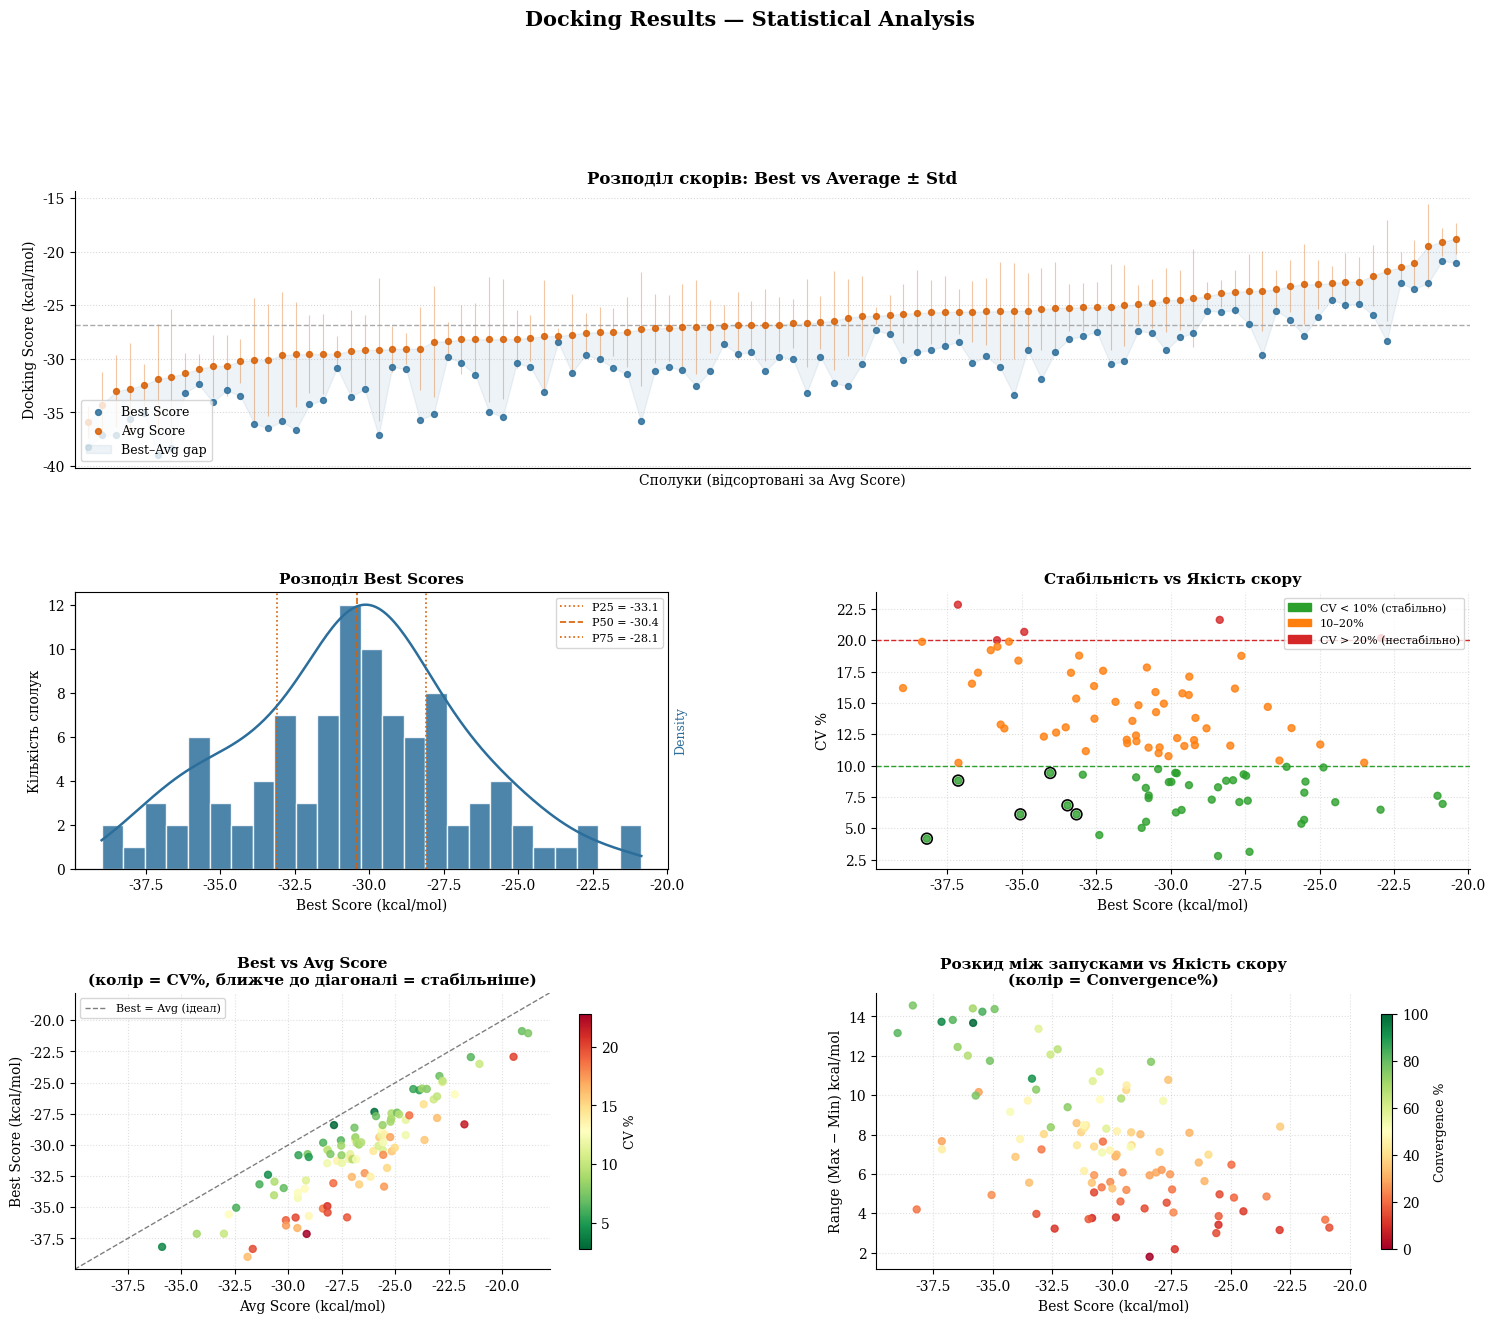

Збережено → docking_analysis_v2.png


In [18]:
# ── Наукова візуалізація результатів докінгу ──────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy import stats

# Палітра
C_BLUE   = "#2C6E9B"
C_CORAL  = "#D95F02"
C_GREEN  = "#2CA02C"
C_ORANGE = "#FF7F0E"
C_RED    = "#D62728"
C_GRAY   = "#AAAAAA"

df = stats_df.sort_values("Avg_Score").reset_index(drop=True)
n  = len(df)
x  = np.arange(n)

fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor("white")
gs  = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.35)

# ── 1. Score distribution: Best vs Avg з error bars ───────────────────────────
ax1 = fig.add_subplot(gs[0, :])

ax1.scatter(x, df["Best_Score"], s=18, color=C_BLUE,  zorder=3, label="Best Score",  alpha=0.85)
ax1.scatter(x, df["Avg_Score"],  s=18, color=C_CORAL, zorder=3, label="Avg Score",   alpha=0.85)
ax1.errorbar(x, df["Avg_Score"], yerr=df["Std_Score"],
             fmt="none", color=C_CORAL, alpha=0.35, linewidth=0.8, capsize=0, zorder=2)

# Заштрихована зона між Best і Avg
ax1.fill_between(x, df["Best_Score"], df["Avg_Score"],
                 alpha=0.08, color=C_BLUE, label="Best–Avg gap")

ax1.set_xlim(-1, n)
ax1.set_xticks([])
ax1.set_xlabel("Сполуки (відсортовані за Avg Score)", fontsize=10)
ax1.set_ylabel("Docking Score (kcal/mol)", fontsize=10)
ax1.set_title("Розподіл скорів: Best vs Average ± Std", fontsize=12, fontweight="bold")
ax1.legend(fontsize=9, loc="lower left")
ax1.axhline(df["Avg_Score"].median(), color=C_GRAY, linestyle="--", linewidth=1,
            label=f"Median avg = {df['Avg_Score'].median():.1f}")
ax1.grid(axis="y", linestyle=":", alpha=0.5)
ax1.spines[["top","right"]].set_visible(False)

# ── 2. Histogram: розподіл Best Scores ────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])

ax2.hist(df["Best_Score"], bins=25, color=C_BLUE, edgecolor="white", alpha=0.85)
# KDE поверх гістограми
kde_x = np.linspace(df["Best_Score"].min(), df["Best_Score"].max(), 200)
kde   = stats.gaussian_kde(df["Best_Score"])
ax2_twin = ax2.twinx()
ax2_twin.plot(kde_x, kde(kde_x), color=C_BLUE, linewidth=1.8)
ax2_twin.set_ylabel("Density", fontsize=9, color=C_BLUE)
ax2_twin.tick_params(axis="y", labelcolor=C_BLUE)
ax2_twin.set_yticks([])

# Перцентилі
for p, ls in [(25, ":"), (50, "--"), (75, ":")]:
    v = np.percentile(df["Best_Score"], p)
    ax2.axvline(v, color=C_CORAL, linestyle=ls, linewidth=1.2,
                label=f"P{p} = {v:.1f}")

ax2.set_xlabel("Best Score (kcal/mol)", fontsize=10)
ax2.set_ylabel("Кількість сполук", fontsize=10)
ax2.set_title("Розподіл Best Scores", fontsize=11, fontweight="bold")
ax2.legend(fontsize=8)
ax2.spines[["top","right"]].set_visible(False)

# ── 3. CV% vs Best Score — scatter зі стабільністю ───────────────────────────
ax3 = fig.add_subplot(gs[1, 1])

colors_cv = df["CV_%"].apply(
    lambda v: C_GREEN if v < 10 else C_ORANGE if v < 20 else C_RED
)
sc = ax3.scatter(df["Best_Score"], df["CV_%"], c=colors_cv, s=25, alpha=0.8, zorder=3)

ax3.axhline(10, color=C_GREEN,  linestyle="--", linewidth=1, label="CV = 10% (стабільно)")
ax3.axhline(20, color=C_RED,    linestyle="--", linewidth=1, label="CV = 20% (нестабільно)")

# Виділяємо "ідеальних кандидатів": низький скор + низький CV
ideal = df[(df["Best_Score"] < df["Best_Score"].quantile(0.25)) & (df["CV_%"] < 10)]
if not ideal.empty:
    ax3.scatter(ideal["Best_Score"], ideal["CV_%"],
                s=60, facecolors="none", edgecolors="black", linewidths=1.2,
                zorder=4, label=f"Ідеальні кандидати (n={len(ideal)})")

patches = [
    mpatches.Patch(color=C_GREEN,  label="CV < 10% (стабільно)"),
    mpatches.Patch(color=C_ORANGE, label="10–20%"),
    mpatches.Patch(color=C_RED,    label="CV > 20% (нестабільно)"),
]
ax3.legend(handles=patches, fontsize=8)
ax3.set_xlabel("Best Score (kcal/mol)", fontsize=10)
ax3.set_ylabel("CV %", fontsize=10)
ax3.set_title("Стабільність vs Якість скору", fontsize=11, fontweight="bold")
ax3.spines[["top","right"]].set_visible(False)
ax3.grid(linestyle=":", alpha=0.4)

# ── 4. Best Score vs Avg Score — ідеальна збіжність = діагональ ──────────────
ax4 = fig.add_subplot(gs[2, 0])

ax4.scatter(df["Avg_Score"], df["Best_Score"],
            c=df["CV_%"], cmap="RdYlGn_r", s=25, alpha=0.85, zorder=3)
sm = plt.cm.ScalarMappable(cmap="RdYlGn_r",
     norm=plt.Normalize(df["CV_%"].min(), df["CV_%"].max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax4, shrink=0.85)
cbar.set_label("CV %", fontsize=9)

# Лінія ідеальної збіжності (y = x)
lims = [min(df["Avg_Score"].min(), df["Best_Score"].min()) - 1,
        max(df["Avg_Score"].max(), df["Best_Score"].max()) + 1]
ax4.plot(lims, lims, "k--", linewidth=1, alpha=0.5, label="Best = Avg (ідеал)")
ax4.set_xlim(lims); ax4.set_ylim(lims)
ax4.set_xlabel("Avg Score (kcal/mol)", fontsize=10)
ax4.set_ylabel("Best Score (kcal/mol)", fontsize=10)
ax4.set_title("Best vs Avg Score\n(колір = CV%, ближче до діагоналі = стабільніше)",
              fontsize=11, fontweight="bold")
ax4.legend(fontsize=8)
ax4.spines[["top","right"]].set_visible(False)
ax4.grid(linestyle=":", alpha=0.4)

# ── 5. Range Score — розкид між запусками ─────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])

ax5.scatter(df["Best_Score"], df["Range_Score"],
            c=df["Convergence"], cmap="RdYlGn", s=25, alpha=0.85, zorder=3)
sm2 = plt.cm.ScalarMappable(cmap="RdYlGn",
      norm=plt.Normalize(0, 100))
sm2.set_array([])
cbar2 = plt.colorbar(sm2, ax=ax5, shrink=0.85)
cbar2.set_label("Convergence %", fontsize=9)

ax5.set_xlabel("Best Score (kcal/mol)", fontsize=10)
ax5.set_ylabel("Range (Max − Min) kcal/mol", fontsize=10)
ax5.set_title("Розкид між запусками vs Якість скору\n(колір = Convergence%)",
              fontsize=11, fontweight="bold")
ax5.spines[["top","right"]].set_visible(False)
ax5.grid(linestyle=":", alpha=0.4)

fig.suptitle("Docking Results — Statistical Analysis", fontsize=15, fontweight="bold", y=1.01)

plt.savefig("docking_analysis_v2.png", dpi=200, bbox_inches="tight")
plt.show()
print("Збережено → docking_analysis_v2.png")

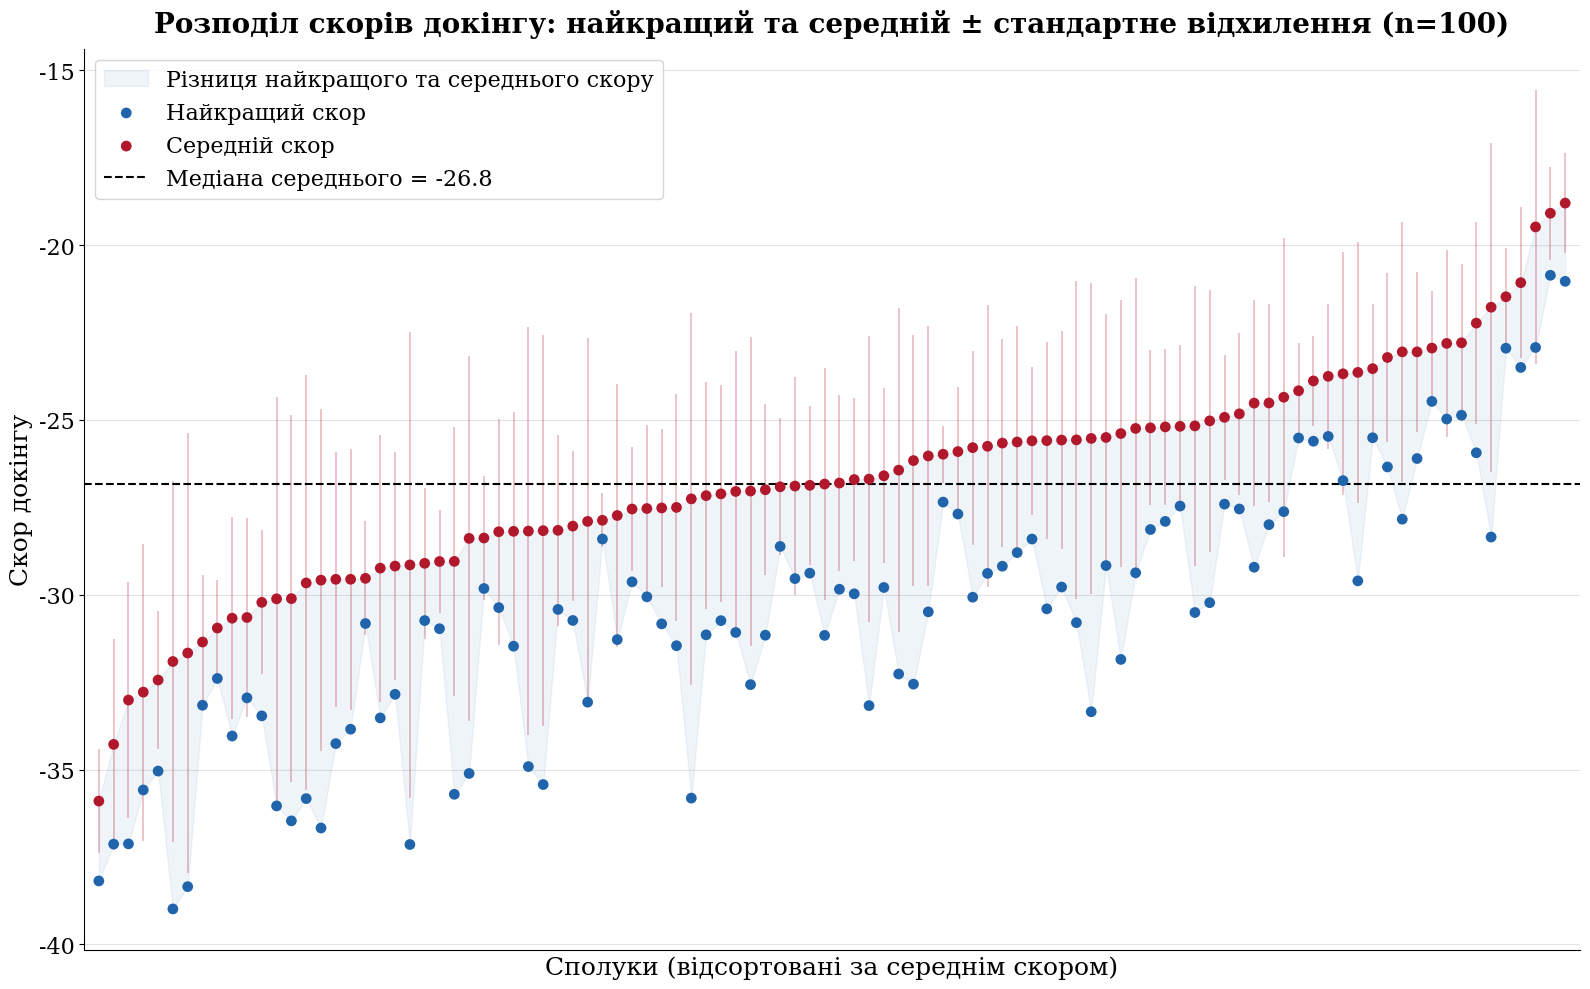

Збережено → docking_fig1_scores.png


In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
from scipy import stats

# ── Глобальні налаштування ──────────────────────────────────────────────────
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif']  = ['Times New Roman', 'DejaVu Serif', 'serif']
plt.rcParams['axes.unicode_minus'] = False

cmap = plt.get_cmap('RdBu_r')
color_best = cmap(0.1)  # deep red
color_avg  = cmap(0.9)  # blue

# Сортування даних
stats_df = pd.read_csv("../data/docking_outputs/docking_results_with_stats.csv")
df = stats_df.sort_values("Avg_Score").reset_index(drop=True)
n = len(df)
x = np.arange(n)

# ════════════════════════════════════════════════════════════════════════════════
# ГРАФІК 1 — Розподіл скорів: Best vs Average ± Std
# ════════════════════════════════════════════════════════════════════════════════

fig1, ax = plt.subplots(figsize=(16, 10))

# 1. Заповнення між найкращим та середнім значенням
ax.fill_between(x, df["Best_Score"], df["Avg_Score"],
                alpha=0.07, color=color_best, label="Різниця найкращого та середнього скору")

# 2. Стандартне відхилення (помилки)
ax.errorbar(x, df["Avg_Score"], yerr=df["Std_Score"],
            fmt="none", color=color_avg, alpha=0.3, linewidth=1.2, zorder=2)

# 3. Точки даних
ax.scatter(x, df["Best_Score"], s=60, color=color_best, zorder=4,
           label="Найкращий скор", edgecolors="none")
ax.scatter(x, df["Avg_Score"],  s=60, color=color_avg,  zorder=4,
           label="Середній скор",  edgecolors="none")

# 4. Медіана
median_val = df["Avg_Score"].median()
ax.axhline(median_val, color="black", linestyle="--", linewidth=1.5,
           label=f"Медіана середнього = {median_val:.1f}")

# Оформлення осей та підписи (розміри шрифтів: 18, 20, 16)
ax.set_xlim(-1, n)
ax.set_xticks([])
ax.set_xlabel("Сполуки (відсортовані за середнім скором)", fontsize=18)
ax.set_ylabel("Скор докінгу", fontsize=18)
ax.set_title("Розподіл скорів докінгу: найкращий та середній ± стандартне відхилення (n=100)",
             fontsize=20, fontweight="bold", pad=12)

ax.legend(fontsize=16, frameon=True, loc="upper left")
ax.grid(True, axis="y", linestyle="-", alpha=0.35)
ax.tick_params(axis="both", labelsize=16)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("docking_fig1_scores.png", dpi=400, bbox_inches="tight")
plt.show()
print("Збережено → docking_fig1_scores.png")

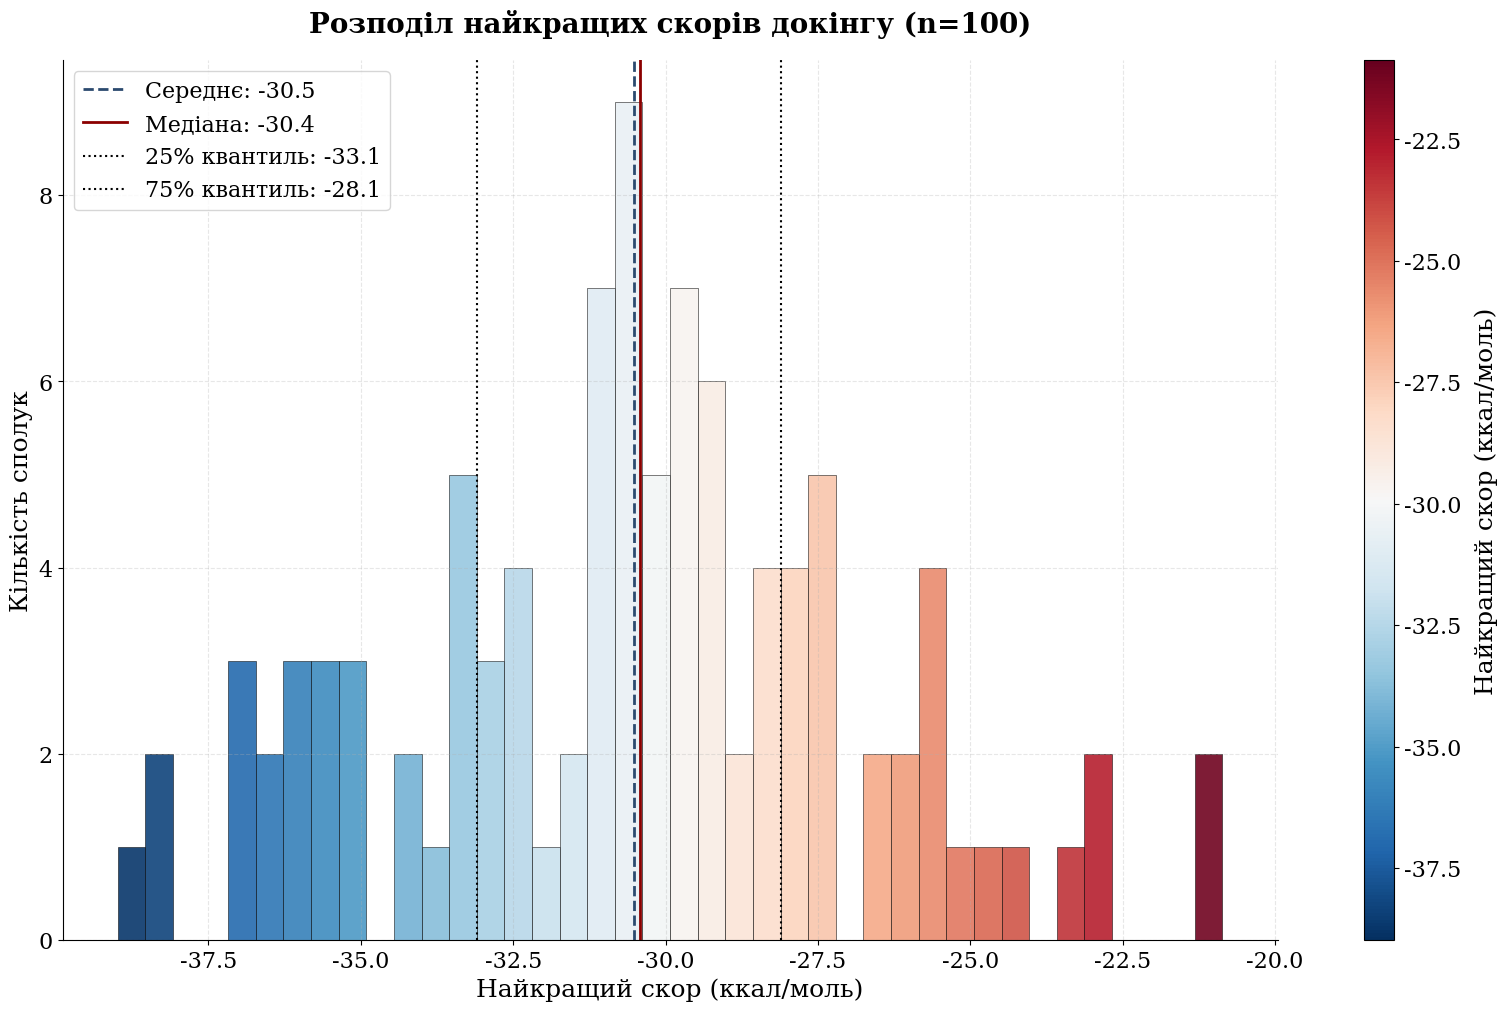

In [20]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from scipy import stats

# ── Налаштування стилю ───────────────────────────────────────────────────────
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif']  = ['Times New Roman', 'DejaVu Serif', 'serif']
plt.rcParams['axes.unicode_minus'] = False

cmap = plt.get_cmap('RdBu_r')

# ════════════════════════════════════════════════════════════════════════════════
# ГРАФІК 2 — Виправлена версія без накладань
# ════════════════════════════════════════════════════════════════════════════════

fig2, ax = plt.subplots(figsize=(15, 10), constrained_layout=True)

score_data = df["Best_Score"]
bs_min, bs_max = score_data.min(), score_data.max()
norm2 = mpl.colors.Normalize(vmin=bs_min, vmax=bs_max)

# 1. Гістограма
n_bins = 40
counts, bins, patches = ax.hist(score_data, bins=n_bins, density=False,
                                edgecolor="black", linewidth=0.4, alpha=0.9)

for bin_l, bin_r, patch in zip(bins[:-1], bins[1:], patches):
    patch.set_facecolor(cmap(norm2((bin_l + bin_r) / 2)))

# 2. KDE (Крива розподілу)
#kde_x = np.linspace(bs_min, bs_max, 300)
#kde   = stats.gaussian_kde(score_data)
#ax_twin = ax.twinx()
#ax_twin.plot(kde_x, kde(kde_x), color="black", linewidth=1.5, zorder=5)

# 3. Статистичні лінії
mean_val   = score_data.mean()
median_val = score_data.median()
p25, p75   = np.percentile(score_data, [25, 75])

ax.axvline(mean_val,   color="#2B4A6F", linestyle="--", linewidth=2,
           label=f"Середнє: {mean_val:.1f}")
ax.axvline(median_val, color="darkred", linestyle="-",  linewidth=2,
           label=f"Медіана: {median_val:.1f}")
ax.axvline(p25, color="black", linestyle=":", linewidth=1.5,
           label=f"25% квантиль: {p25:.1f}")
ax.axvline(p75, color="black", linestyle=":", linewidth=1.5,
           label=f"75% квантиль: {p75:.1f}")

# 4. Оформлення
ax.set_xlabel("Найкращий скор (ккал/моль)", fontsize=18)
ax.set_ylabel("Кількість сполук", fontsize=18)
ax.set_title("Розподіл найкращих скорів докінгу (n=100)",
             fontsize=20, fontweight="bold", pad=20)

ax.legend(fontsize=16, frameon=True, loc="upper left")
ax.grid(True, linestyle="--", alpha=0.3)
ax.tick_params(axis="both", labelsize=16)

# Прибираємо рамки
ax.spines[["top", "right"]].set_visible(False)
#ax_twin.spines[["top", "right"]].set_visible(False)

# 5. Colorbar (шкала кольорів)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm2)
cbar = fig2.colorbar(sm, ax=ax, pad=0.05, aspect=30)
cbar.set_label("Найкращий скор (ккал/моль)", fontsize=18, labelpad=10)
cbar.ax.tick_params(labelsize=16)

plt.savefig("docking_fig2_fixed.png", dpi=400)
plt.show()

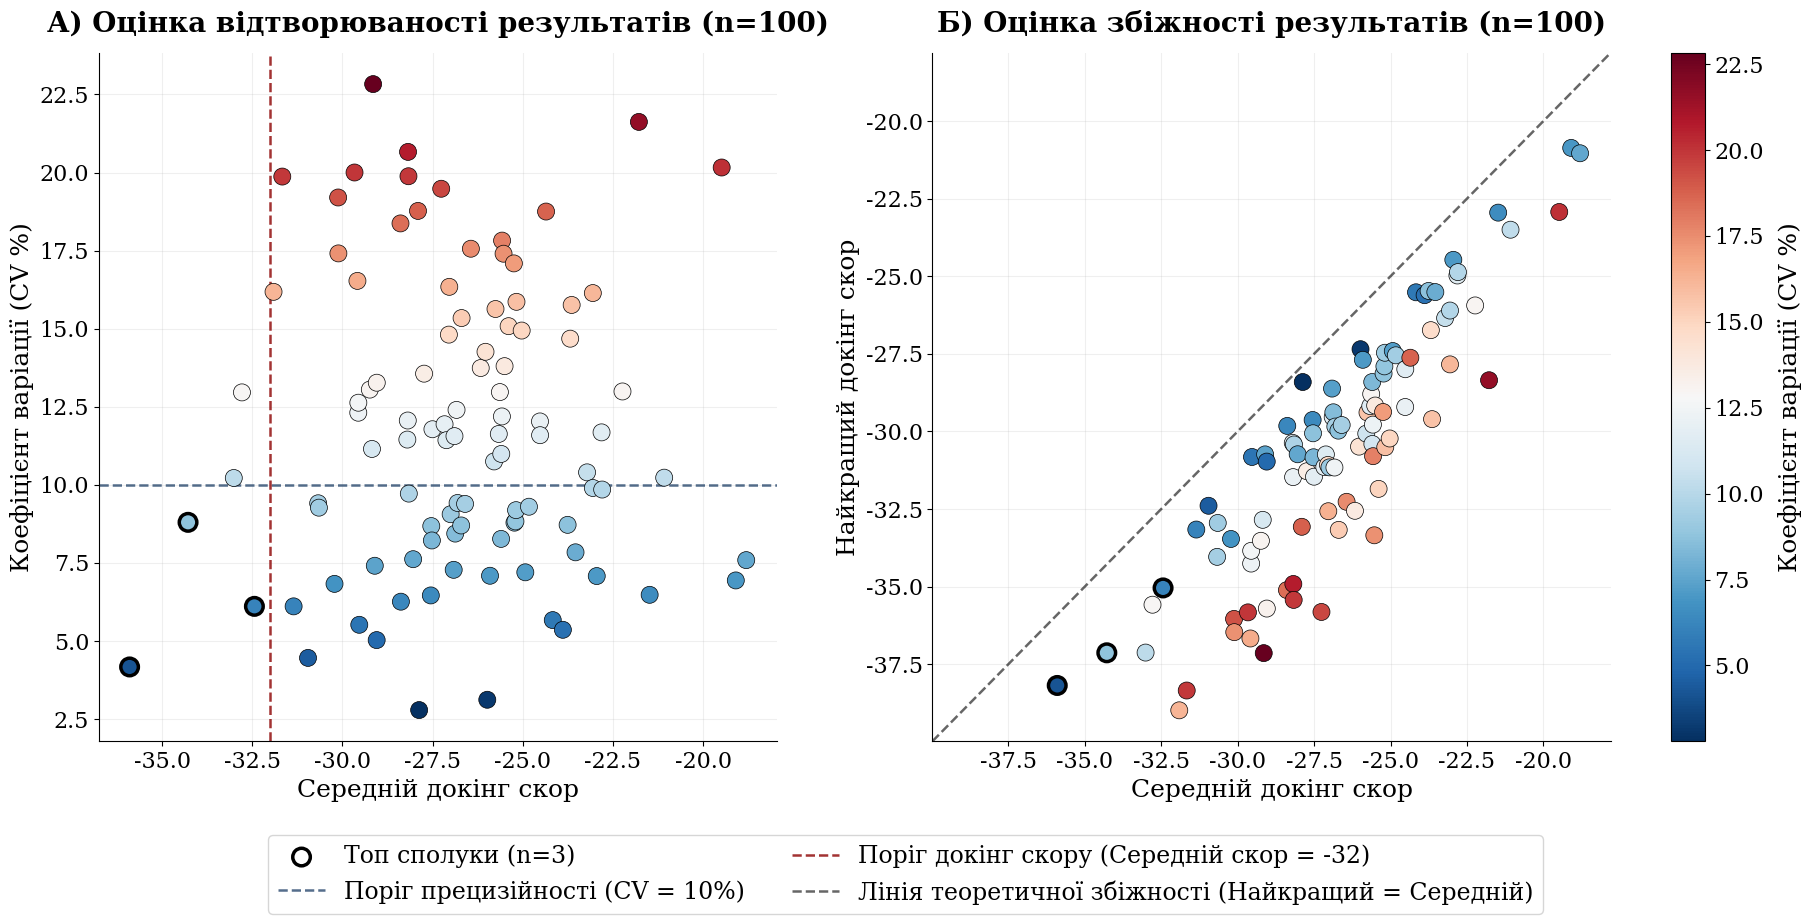

In [5]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import numpy as np

# ── Налаштування стилю ───────────────────────────────────────────────────────
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif']  = ['Times New Roman', 'DejaVu Serif', 'serif']
plt.rcParams['axes.unicode_minus'] = False

cmap = plt.get_cmap('RdBu_r')

# ════════════════════════════════════════════════════════════════════════════════
# ГРАФІК 3 — Аналіз стабільності та збіжності зі спільною легендою
# ════════════════════════════════════════════════════════════════════════════════

# Створюємо фігуру. Додаємо трохи висоти для легенди знизу
fig = plt.figure(figsize=(18, 8), constrained_layout=True)
gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 1, 0.05], wspace=0.1)

ax_l = fig.add_subplot(gs[0])
ax_r = fig.add_subplot(gs[1])
ax_cbar = fig.add_subplot(gs[2])

cv_min, cv_max = df["CV_%"].min(), df["CV_%"].max()
norm_cv = mpl.colors.Normalize(vmin=cv_min, vmax=cv_max)

# Розрахунок ідеальних сполук: CV < 10% та Avg_Score < -32
ideal = df[(df["CV_%"] < 10) & (df["Avg_Score"] < -32)]

# ── Ліво: Аналіз відтворюваності ──────────────────────────────────────────
sc1 = ax_l.scatter(df["Avg_Score"], df["CV_%"],
                  c=df["CV_%"], cmap=cmap, norm=norm_cv, 
                  s=150, edgecolors="black", linewidths=0.5, zorder=3)

# Підсвічування ідеальних (зберігаємо об'єкт для легенди)
h_ideal = None
if not ideal.empty:
    h_ideal = ax_l.scatter(ideal["Avg_Score"], ideal["CV_%"],
                  s=160, facecolors="none", edgecolors="black",
                  linewidths=2.5, zorder=5, label=f"Топ сполуки (n={len(ideal)})")

h_cv = ax_l.axhline(10, color="#2B4A6F", linestyle="--", linewidth=1.8, alpha=0.8, 
                    label="Поріг прецизійності (CV = 10%)")
h_energy = ax_l.axvline(-32, color="darkred", linestyle="--", linewidth=1.8, alpha=0.8, 
                        label="Поріг докінг скору (Середній скор = -32)")

ax_l.set_xlabel("Середній докінг скор", fontsize=18)
ax_l.set_ylabel("Коефіцієнт варіації (CV %)", fontsize=18)
ax_l.set_title("А) Оцінка відтворюваності результатів (n=100)", fontsize=20, fontweight="bold", pad=15)
ax_l.grid(True, linestyle="-", alpha=0.2)

# ── Право: Оцінка збіжності ──────────────────────────────────────────────────
sc2 = ax_r.scatter(df["Avg_Score"], df["Best_Score"],
                   c=df["CV_%"], cmap=cmap, norm=norm_cv, 
                   s=150, edgecolors="black", linewidths=0.5, zorder=3)

if not ideal.empty:
    ax_r.scatter(ideal["Avg_Score"], ideal["Best_Score"],
                  s=160, facecolors="none", edgecolors="black",
                  linewidths=2.5, zorder=5)

# Лінія ідеальної збіжності
combined_min = min(df["Avg_Score"].min(), df["Best_Score"].min()) - 1
combined_max = max(df["Avg_Score"].max(), df["Best_Score"].max()) + 1
lims = [combined_min, combined_max]

h_conv, = ax_r.plot(lims, lims, "k--", linewidth=1.8, alpha=0.6, 
                    label="Лінія теоретичної збіжності (Найкращий = Середній)")
ax_r.set_xlim(lims)
ax_r.set_ylim(lims)

ax_r.set_xlabel("Середній докінг скор", fontsize=18)
ax_r.set_ylabel("Найкращий докінг скор", fontsize=18)
ax_r.set_title("Б) Оцінка збіжності результатів (n=100)", fontsize=20, fontweight="bold", pad=15)
ax_r.grid(True, linestyle="-", alpha=0.2)

# ── Спільний Colorbar ────────────────────────────────────────────────────────
cbar = fig.colorbar(sc1, cax=ax_cbar)
cbar.set_label("Коефіцієнт варіації (CV %)", fontsize=18, labelpad=10)
cbar.ax.tick_params(labelsize=16)

# ── СТВОРЕННЯ СПІЛЬНОЇ ЛЕГЕНДИ ЗНИЗУ ─────────────────────────────────────────
# Збираємо всі унікальні елементи
handles = [h_ideal, h_cv, h_energy, h_conv]
# Фільтруємо None, якщо раптом ідеальних сполук немає
handles = [h for h in handles if h is not None]
labels = [h.get_label() for h in handles]

# Розміщуємо легенду під графіками
legend = fig.legend(handles, labels, 
                    loc='lower center', 
                    bbox_to_anchor=(0.5, -0.15), 
                    ncol=2, 
                    fontsize=17, 
                    frameon=True, 
                    edgecolor="0.8")

# Оформлення осей
for ax_item in [ax_l, ax_r]:
    ax_item.spines[["top", "right"]].set_visible(False)
    ax_item.tick_params(axis="both", labelsize=16)

plt.savefig("docking_fig3_reproducibility.png", dpi=400, bbox_inches="tight")
plt.show()

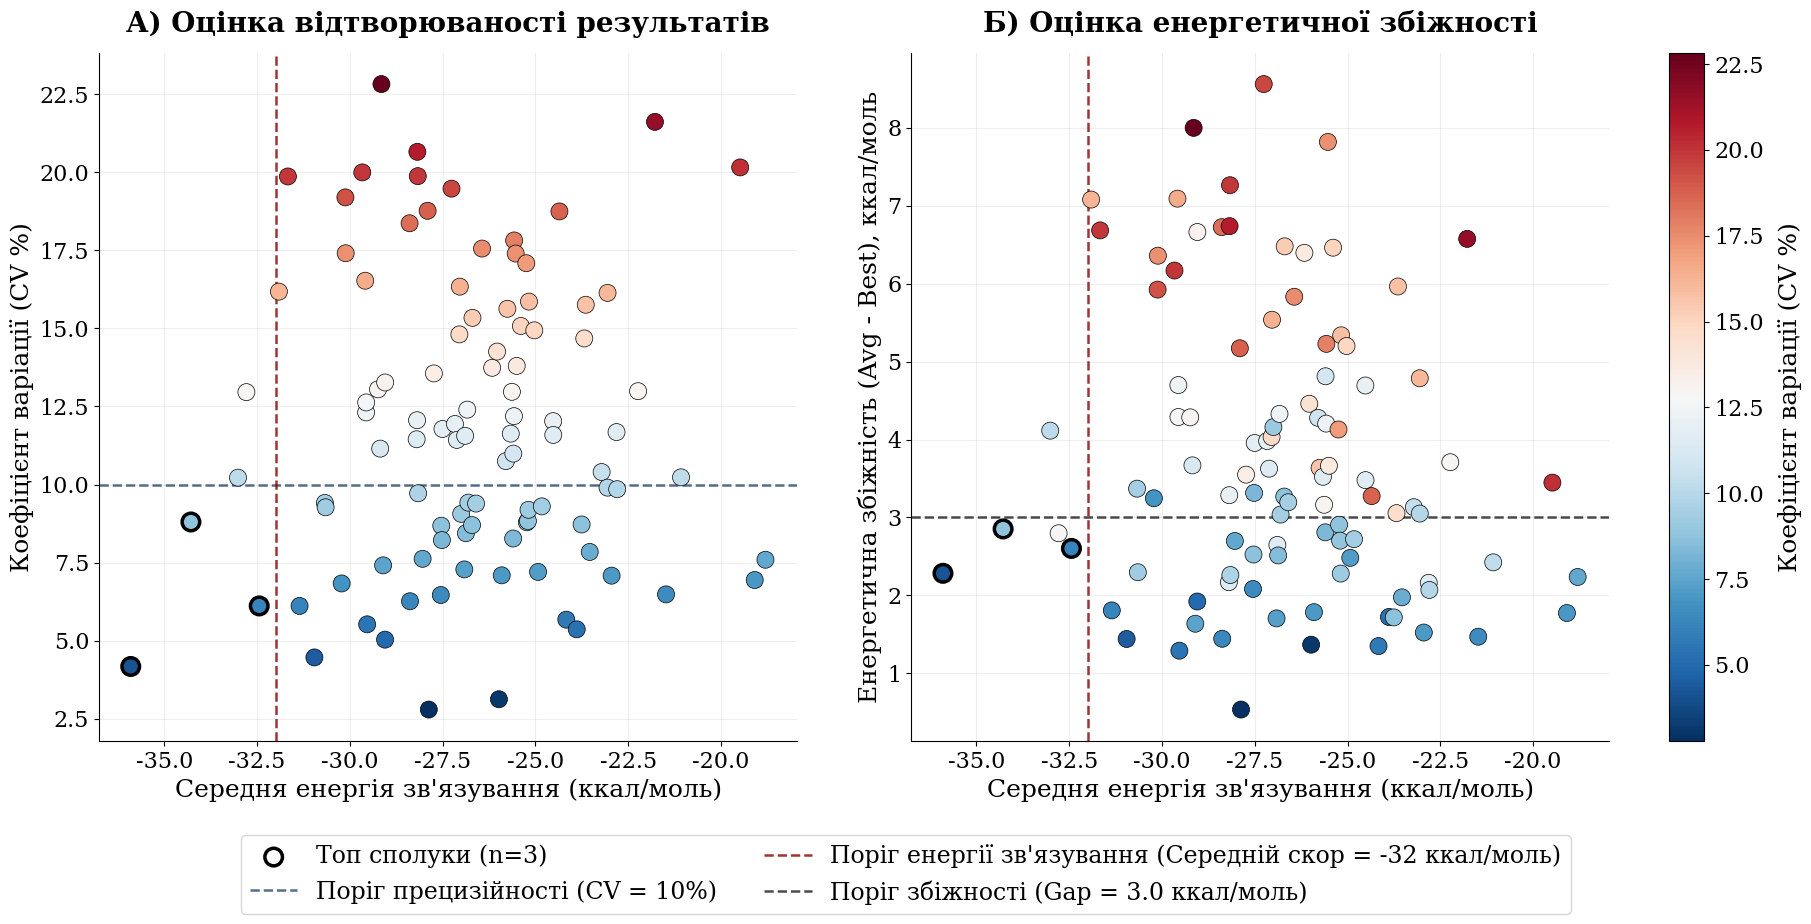

Розрахунок завершено. Середня збіжність (Gap) по вибірці: 3.76 ккал/моль


In [26]:
# ════════════════════════════════════════════════════════════════════════════════
# ГРАФІК 3 — Аналіз прецизійності та енергетичної збіжності (Convergence)
# ════════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18, 8), constrained_layout=True)
gs = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 1, 0.05], wspace=0.1)

ax_l = fig.add_subplot(gs[0])
ax_r = fig.add_subplot(gs[1])
ax_cbar = fig.add_subplot(gs[2])

cv_min, cv_max = df["CV_%"].min(), df["CV_%"].max()
norm_cv = mpl.colors.Normalize(vmin=cv_min, vmax=cv_max)

# Розрахунок ідеальних сполук (за середнім)
ideal = df[(df["CV_%"] < 10) & (df["Avg_Score"] < -32)]

# ── А) Ліво: Аналіз відтворюваності (CV % vs Avg Score) ───────────────────
sc1 = ax_l.scatter(df["Avg_Score"], df["CV_%"],
                  c=df["CV_%"], cmap=cmap, norm=norm_cv, 
                  s=150, edgecolors="black", linewidths=0.5, zorder=3)

# Підсвічування топ-сполук
h_ideal = None
if not ideal.empty:
    h_ideal = ax_l.scatter(ideal["Avg_Score"], ideal["CV_%"],
                  s=160, facecolors="none", edgecolors="black",
                  linewidths=2.5, zorder=5, label=f"Топ сполуки (n={len(ideal)})")

h_cv = ax_l.axhline(10, color="#2B4A6F", linestyle="--", linewidth=1.8, alpha=0.8, 
                    label="Поріг прецизійності (CV = 10%)")
h_energy = ax_l.axvline(-32, color="darkred", linestyle="--", linewidth=1.8, alpha=0.8, 
                        label="Поріг енергії зв'язування (Середній скор = -32 ккал/моль)")

ax_l.set_xlabel("Середня енергія зв'язування (ккал/моль)", fontsize=18)
ax_l.set_ylabel("Коефіцієнт варіації (CV %)", fontsize=18)
ax_l.set_title("А) Оцінка відтворюваності результатів", fontsize=20, fontweight="bold", pad=15)
ax_l.grid(True, linestyle="-", alpha=0.2)

# ── Б) Право: Оцінка збіжності (Convergence Gap vs Avg Score) ───────────
# Використовуємо Convergence (Avg - Best) на осі Y
sc2 = ax_r.scatter(df["Avg_Score"], df["Convergence"],
                   c=df["CV_%"], cmap=cmap, norm=norm_cv, 
                   s=150, edgecolors="black", linewidths=0.5, zorder=3)

if not ideal.empty:
    ax_r.scatter(ideal["Avg_Score"], ideal["Convergence"],
                  s=160, facecolors="none", edgecolors="black",
                  linewidths=2.5, zorder=5)

# Поріг збіжності (наприклад, дельта 2.0 ккал/моль вважається прийнятною)
h_conv_limit = ax_r.axhline(3.0, color="black", linestyle="--", linewidth=1.8, alpha=0.7, 
                           label="Поріг збіжності (Gap = 3.0 ккал/моль)")
h_energy = ax_r.axvline(-32, color="darkred", linestyle="--", linewidth=1.8, alpha=0.8, 
                        label="Поріг енергії зв'язування (Середній скор = -32 ккал/моль)")

ax_r.set_xlabel("Середня енергія зв'язування (ккал/моль)", fontsize=18)
ax_r.set_ylabel("Енергетична збіжність (Avg - Best), ккал/моль", fontsize=18)
ax_r.set_title("Б) Оцінка енергетичної збіжності", fontsize=20, fontweight="bold", pad=15)
ax_r.grid(True, linestyle="-", alpha=0.2)

# ── Спільний Colorbar (без змін) ──────────────────────────────────────────
cbar = fig.colorbar(sc1, cax=ax_cbar)
cbar.set_label("Коефіцієнт варіації (CV %)", fontsize=18, labelpad=10)
cbar.ax.tick_params(labelsize=16)

# ── Спільна легенда знизу (без змін) ─────────────────────────────────────
handles = [h_ideal, h_cv, h_energy, h_conv_limit]
handles = [h for h in handles if h is not None]
labels = [h.get_label() for h in handles]

legend = fig.legend(handles, labels, 
                    loc='lower center', 
                    bbox_to_anchor=(0.5, -0.15), 
                    ncol=2, 
                    fontsize=17, 
                    frameon=True, 
                    edgecolor="0.8")

# Оформлення осей
for ax_item in [ax_l, ax_r]:
    ax_item.spines[["top", "right"]].set_visible(False)
    ax_item.tick_params(axis="both", labelsize=16)

plt.savefig("docking_fig3_reproducibility.png", dpi=400, bbox_inches="tight")
plt.show()

print(f"Розрахунок завершено. Середня збіжність (Gap) по вибірці: {df['Convergence'].mean():.2f} ккал/моль")